# Generating New Images Through CFM using CIFAR-10 Image Dataset 
### Harivansh Luchmun

I received help from generative models such as Github Copilot and Perplexity in the generation of this code. The intention behind this notebook is to try and generate some new images using the ideas of conditional flow matching. This notebook does not feature the common targeted libraries like torchcfm that other notebooks used and it is more to implement the idea from scratch and get a hands on experience.

## Imports
This portion of the code is responsible for many imports involving the neural network and the CIFAR dataset.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader 
from torchvision import datasets, transforms #Used to import the datasets and transform them
import matplotlib.pyplot as plt #Used for plotting

%matplotlib inline

# Checks if GPU can be used, if not it uses CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Data Manipulation 
The cell below is responsible for loading in the training and testing dataset and transforming them to make it easier to train.

In [ ]:
# This part is used to transform the images into tensors and normalize the data
# so that it will be easier to train.
transform = transforms.Compose([
    transforms.ToTensor(),  # This part tranforms the images into tensors and scales them to be in [0, 1]
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))  # This normalizes the tensor to have values in the range [-1, 1]
])

# The parts below load in the CIFAR-10 dataset for training and testing and applies the transformations.
train_dataset = datasets.CIFAR10(
    root="./data", # Stores the data at the data directory
    train=True, # Asks for training data
    download=True, # Downloads if not already installed
    transform=transform, # Applies transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# This part creates a Dataloader which lets us see batches of the dataset at a time
batch_size = 128 # Sets number of images for a batch
train_loader = DataLoader(
    train_dataset, # Takes in the training dataset
    batch_size=batch_size,
    shuffle=True, # Switches the order of the data
    num_workers=2, # Defines two subprocesses for loading the data
    pin_memory=True, # Saves memory and works faster if a GPU is available
)

classes = train_dataset.classes
print("CIFAR-10 classes:", classes) #This shows the categories in the data file


100%|██████████| 170M/170M [00:23<00:00, 7.40MB/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified
CIFAR-10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


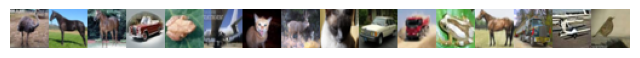

['bird', 'horse', 'horse', 'automobile', 'frog', 'airplane', 'cat', 'deer', 'cat', 'automobile', 'truck', 'frog', 'horse', 'truck', 'airplane', 'bird']


In [ ]:
# The cell below is responsible for showing a few of the images from a batch and their 
# corresponding labels
def show_cifar_batch(loader):
    images, labels = next(iter(loader))
    images = (images[:16] + 1) * 0.5  # back to [0,1]
    grid = torch.cat([images[i] for i in range(len(images))], dim=2)
    plt.figure(figsize=(8, 2))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.show()
    print([classes[l] for l in labels[:16]])

show_cifar_batch(train_loader)


## Neural Network

In [ ]:


class SimpleCFMUNetCIFAR(nn.Module):
    def __init__(self, num_classes=10, time_emb_dim=64):
        super().__init__()
        self.num_classes = num_classes

        # Embeddings
        self.label_emb = nn.Embedding(num_classes, time_emb_dim) # Turns the labels into a vector 
        # Sets the embedding as a time vector 
        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
        )

        # Project conditioning down to 4 channels total
        self.cond_proj = nn.Linear(time_emb_dim, 4)

        in_channels = 3 + 4   # 3 image + 4 conditioning channels
        base = 64 # Base number of channels

        # This part is the architecture of the UNet

        # This is the part is the input to the Unet that projects it to the base number of channels
        self.conv_in = nn.Conv2d(in_channels, base, 3, padding=1)

        # This is the first downsampling. Downsampling allows for more channels to define more features.  
        self.down1 = nn.Sequential(
            # Takes in teh base number of channesls and doubles it, while also reducing the spatial dimensions by half
            nn.Conv2d(base, base * 2, 3, stride=2, padding=1),  # 32 -> 16
            nn.GroupNorm(16, base * 2),
            nn.SiLU(),
        )
        # Repeats the same downsampling process as before
        self.down2 = nn.Sequential(
            nn.Conv2d(base * 2, base * 4, 3, stride=2, padding=1),  # 16 -> 8
            nn.GroupNorm(32, base * 4),
            nn.SiLU(),
        )

        # Since this is where the spatial dimensions are the smallest, we have more channels and add more activations. 
        self.mid = nn.Sequential(
            nn.Conv2d(base * 4, base * 4, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(base * 4, base * 4, 3, padding=1),
            nn.SiLU(),
        )

        # The upsampling process is where we now decrease these channels and increase spatial dimensions back to the image size we want

        self.up1 = nn.Sequential(
            # Takes in the current number of channels and halves it.
            nn.ConvTranspose2d(base * 4, base * 2, 4, stride=2, padding=1),  # 8 -> 16
            nn.GroupNorm(16, base * 2),
            nn.SiLU(),
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(base * 2, base, 4, stride=2, padding=1),      # 16 -> 32
            nn.GroupNorm(8, base),
            nn.SiLU(),
        )

        # Returns the output to 3 channels for the image and those 3 channels represent the RGB values
        self.conv_out = nn.Conv2d(base, 3, 3, padding=1)



    def forward(self, x, t, y):
        # x: (B,3,32,32) which is batch size, 3 channels for RGB, and 32x32 image size
        # t: (B,) which is the time
        # y: (B,) which is the class label
        B, C, H, W = x.shape #

        # Embeddings
        y_emb = self.label_emb(y) # Each label gets turned into a vector
        t = t.view(B, 1) 
        t_emb = self.time_mlp(t) # Each time value gets turned into a vector
        cond = y_emb + t_emb # Combines the label and time embedding into one vector

        # Project to conditioning vector to 4 channels
        cond_small = self.cond_proj(cond)                # (B, 4)
        cond_small = cond_small.unsqueeze(-1).unsqueeze(-1)  # (B, 4, 1, 1)
        cond_small = cond_small.expand(-1, -1, H, W)         # (B, 4, H, W)

        x_in = torch.cat([x, cond_small], dim=1)         # (B, 3+4, H, W)

        # This is the forward pass through the UNet architecture. We follow the downsampling and upsampling process
        h = self.conv_in(x_in)
        h = self.down1(h)
        h = self.down2(h)
        h = self.mid(h)
        h = self.up1(h)
        h = self.up2(h)
        v = self.conv_out(h)
        return v # This is the output velocity field which is really what the model says the change in the image should be at each time step.


Using device: cuda
SimpleCFMUNetCIFAR
Output shape: torch.Size([2, 3, 32, 32])


In [ ]:
model = SimpleCFMUNetCIFAR(num_classes=10, time_emb_dim=64).to(device) 
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4) # A variation of Adam optimizer that uses weight decay for better generalization.

num_epochs = 20  # Number of epochs to train. Chose a decent sized number for my single GPU.


In [38]:
print(model)

SimpleCFMUNetCIFAR(
  (label_emb): Embedding(10, 64)
  (time_mlp): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): SiLU()
  )
  (cond_proj): Linear(in_features=64, out_features=4, bias=True)
  (conv_in): Conv2d(7, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down1): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): GroupNorm(16, 128, eps=1e-05, affine=True)
    (2): SiLU()
  )
  (down2): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): GroupNorm(32, 256, eps=1e-05, affine=True)
    (2): SiLU()
  )
  (mid): Sequential(
    (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): SiLU()
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): SiLU()
  )
  (up1): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(

## Training the Model

In [ ]:
# This training features adding another sample point along the trajectory path instead of just one. 
# This is to get a better gradient estimate.
def train_one_epoch(model, loader, optimizer, epoch, device):
    model.train()
    total_loss = 0.0 # Holds the total loss for this epoch

    # In charge of loading a batch of data and training the model on that batch
    for batch_idx, (x, y) in enumerate(loader):
        x = x.to(device)  # Random image batch
        y = y.to(device) # Random label batch
        B = x.size(0) # Gets batch size

        # Noise and times
        z = torch.randn_like(x) # Gets a noise image of the same size as the input image
        t = torch.rand(B, device=device) # Gets a random time value within 0 and 1
        s = torch.rand(B, device=device) # Gets another random time from 0 to 1 

        # Interpolations (features two different time steps along the same path)
        x_t = (1 - t).view(B, 1, 1, 1) * z + t.view(B, 1, 1, 1) * x # Interpolates between the noise point and the image
        x_s = (1 - s).view(B, 1, 1, 1) * z + s.view(B, 1, 1, 1) * x

        # True velocity (constant along path)
        v_true = x - z

        v_pred_t = model(x_t, t, y) # Models velocity prediction at this time t and intermediate point
        v_pred_s = model(x_s, s, y)

        # Takes the mean squared error for both points on the path
        loss = F.mse_loss(v_pred_t, v_true) + F.mse_loss(v_pred_s, v_true)


        optimizer.zero_grad() # Clears the gradients from the previous step
        loss.backward()
        optimizer.step() # Updates model parameters

        total_loss += loss.item()

        # Prints the average loss every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f"Epoch {epoch} | Step {batch_idx+1}/{len(loader)} | Loss {total_loss/(batch_idx+1):.4f}")

    return total_loss / len(loader)


In [40]:
for epoch in range(1, num_epochs + 1):
    avg_loss = train_one_epoch(model, train_loader, optimizer, epoch, device)
    print(f"Epoch {epoch} done. Avg loss: {avg_loss:.4f}")


Epoch 1 | Step 100/391 | Loss 1.8228
Epoch 1 | Step 200/391 | Loss 1.4257
Epoch 1 | Step 300/391 | Loss 1.2305
Epoch 1 done. Avg loss: 1.1193
Epoch 2 | Step 100/391 | Loss 0.6830
Epoch 2 | Step 200/391 | Loss 0.6643
Epoch 2 | Step 300/391 | Loss 0.6491
Epoch 2 done. Avg loss: 0.6368
Epoch 3 | Step 100/391 | Loss 0.5863
Epoch 3 | Step 200/391 | Loss 0.5779
Epoch 3 | Step 300/391 | Loss 0.5705
Epoch 3 done. Avg loss: 0.5670
Epoch 4 | Step 100/391 | Loss 0.5431
Epoch 4 | Step 200/391 | Loss 0.5409
Epoch 4 | Step 300/391 | Loss 0.5371
Epoch 4 done. Avg loss: 0.5352
Epoch 5 | Step 100/391 | Loss 0.5263
Epoch 5 | Step 200/391 | Loss 0.5228
Epoch 5 | Step 300/391 | Loss 0.5213
Epoch 5 done. Avg loss: 0.5181
Epoch 6 | Step 100/391 | Loss 0.5101
Epoch 6 | Step 200/391 | Loss 0.5081
Epoch 6 | Step 300/391 | Loss 0.5052
Epoch 6 done. Avg loss: 0.5048
Epoch 7 | Step 100/391 | Loss 0.4961
Epoch 7 | Step 200/391 | Loss 0.4980
Epoch 7 | Step 300/391 | Loss 0.4970
Epoch 7 done. Avg loss: 0.4950
Epoch 

## Evaluating the Model

In [ ]:
@torch.no_grad()
def sample_cifar(model, num_samples=16, label=3, steps=100, device="cpu"):
    
    #Generates new CIFAR-10 images using the model
    
    # num_samples: number of images to generate

    model.eval()  # Sets model to evaluation mode
    
    # Creates a batch of labels, all with the same class
    y = torch.full((num_samples,), label, dtype=torch.long, device=device)
    
    # Start from pure noise sample at t  =0
    x = torch.randn(num_samples, 3, 32, 32, device=device)
    dt = 1.0 / steps
    
    # Inegrate the learned velocity field from t=0 to t=1 using Euler's method
    # Tells us how to move according to the flow the model learned at each time step
    for k in range(steps):
        # Current time 
        t = torch.full((num_samples,), k * dt, device=device)
        
        # Get the predicted velocity at current position x and time t
        v = model(x, t, y)
        
        # Changes the new image to move along the flow
        x = x + dt * v

    # Clamp final output to valid range [-1, 1] to match training normalization
    x = x.clamp(-1.0, 1.0)
    
    return x.cpu()


In [ ]:
def show_cifar_samples(samples, nrow=4):
    # Convert samples from [-1,1] range to [0,1] range
    samples = (samples + 1) * 0.5 
    B = samples.size(0)
    
    # square grid of images
    samples = samples[: nrow * nrow]
    fig, axes = plt.subplots(nrow, nrow, figsize=(nrow*2, nrow*2))
    
    # Iterate through each subplot and display the corresponding image
    for i, ax in enumerate(axes.flat):
        # Rearrange tensor dimensions from (C, H, W) to (H, W, C) for matplotlib
        img = samples[i].permute(1, 2, 0).numpy()
        
        ax.imshow(img)
        ax.axis("off")
    
    plt.show()


## Testing The Model To Generate New Samples

Class label: 5 -> dog


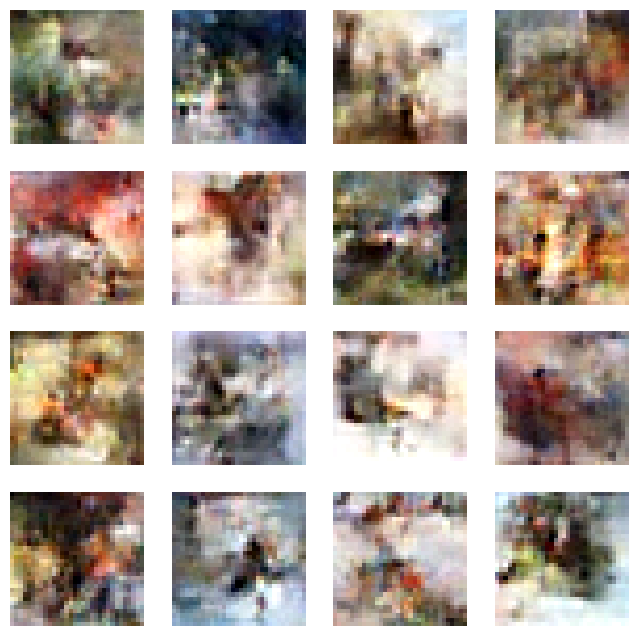

In [ ]:
label = 5  # Choosing label of what to generate
print("Class label:", label, "->", classes[label])

samples = sample_cifar(model, num_samples=16, label=label, steps=100, device=device)
show_cifar_samples(samples)


From the images above it is very unclear what the images are. More epochs for training may have better results if the correct resources are available. In some of the images a snout or legs can be seen althoguht it is very difficult.

## Sampling With More Labels

Label: 0 -> airplane


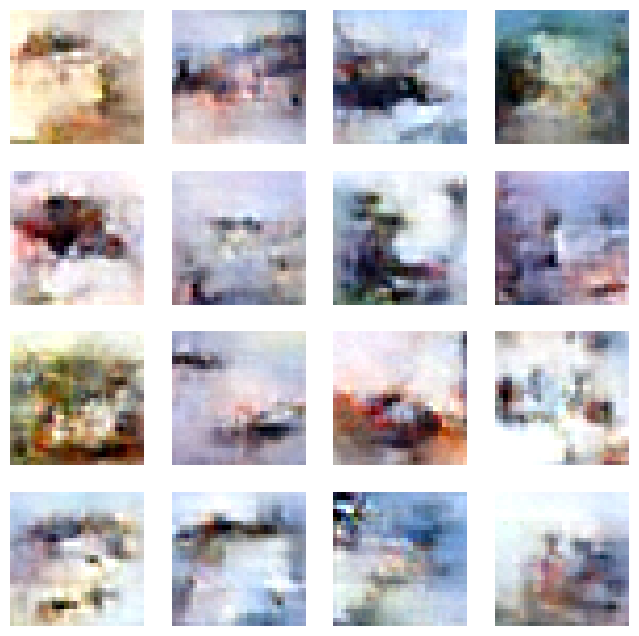

Label: 1 -> automobile


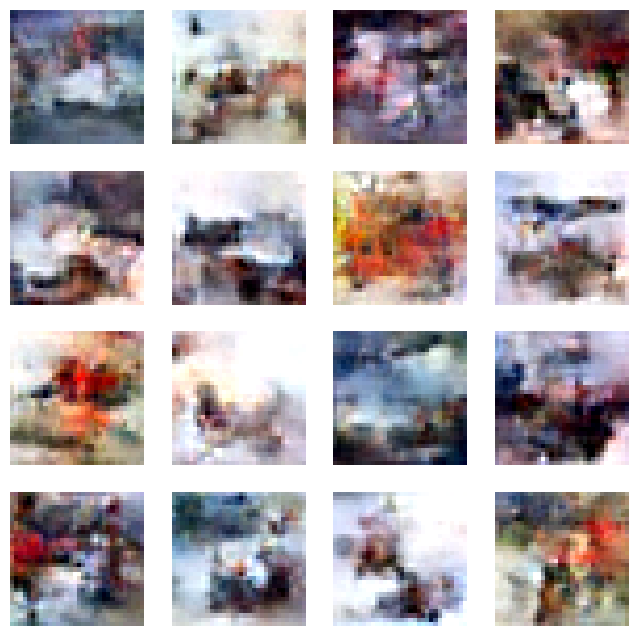

Label: 2 -> bird


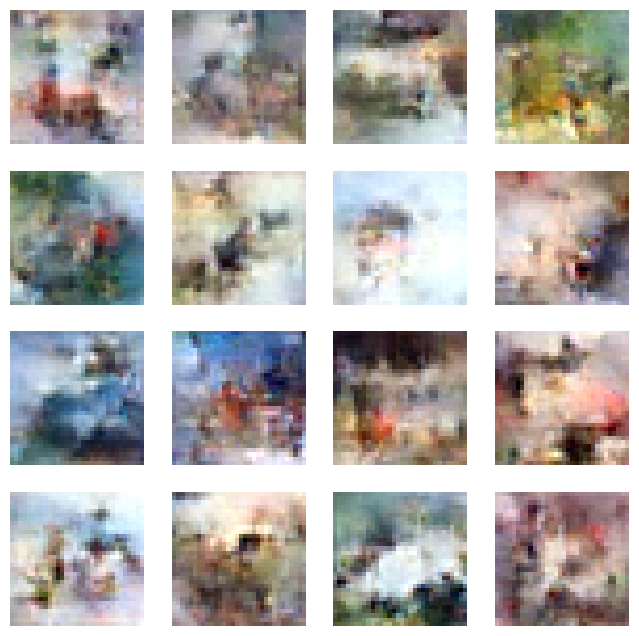

Label: 3 -> cat


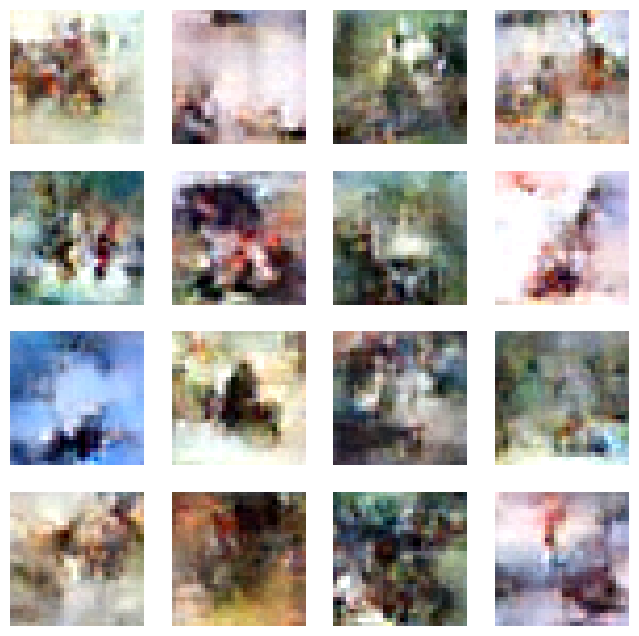

Label: 4 -> deer


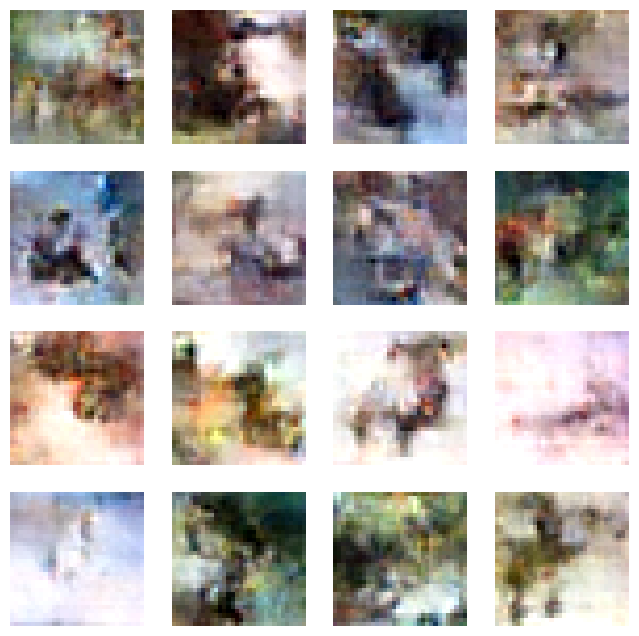

In [44]:
for label in [0, 1, 2, 3, 4]:
    print("Label:", label, "->", classes[label])
    samples = sample_cifar(model, num_samples=16, label=label, steps=100, device=device)
    show_cifar_samples(samples)
